# Polity survivorship — recorded vs estimated total

For ten well-known historical polities we compare:

- **Recorded creators** — number of individuals with at least one *work* in the `works` table (a work = an item in Wikidata: a book, play, composition, film, painting…) attributed to that polity.
- **Chao1-estimated total** — Chao (1984) lower-bound on the *true* number of such creators, including those who left no work that survived in Wikidata at all.
- **Survivorship rate** — recorded / estimated total.

A *singleton* (`f1`) is an individual with exactly **one** work in the `works` table; a *doubleton* (`f2`) has exactly **two**. Chao1's missing-mass formula is

$$\hat f_0 = \frac{f_1(f_1-1)}{2(f_2+1)}.$$

The plot is one normalised horizontal stacked bar per polity: each bar is 100% of the Chao1-estimated total, the coloured share is the recorded fraction, the light share is the estimated unseen mass.

In [1]:
import duckdb
import numpy as np
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import Counter

DB_PATH = "../data/humans_clean.duckdb"

FIGSIZE = (9.5, 5.5)
DPI = 120
COLOR_RECORDED = "#2171b5"
COLOR_ESTIMATED = "#b5542a"
COLOR_LINK = "#cfcfcf"
COLOR_TEXT = "#444444"

mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

## Chao1 estimator (works basis)

Treat each individual as a *species* and each work in the `works` table attributed to them as one *capture*. Let $f_k$ be the number of individuals with exactly $k$ works. The bias-corrected Chao1 lower bound on the unseen mass is

$$\hat f_0 = \frac{f_1 (f_1 - 1)}{2 (f_2 + 1)},$$

and the estimated total richness is $\hat S = S_{\text{obs}} + \hat f_0$, where $S_{\text{obs}}$ is the number of individuals with at least one work.

In [2]:
def chao1(work_counts) -> dict:
    """Chao1 lower-bound richness from a vector of per-individual work counts.
    Accepts a polars Series, numpy array, or list of ints."""
    if hasattr(work_counts, 'to_numpy'):
        arr = work_counts.to_numpy()
    else:
        arr = np.asarray(work_counts)
    counts = Counter(int(v) for v in arr)
    f1 = int(counts.get(1, 0))
    f2 = int(counts.get(2, 0))
    n_obs = int((arr >= 1).sum())
    if f2 > 0:
        f0 = f1 * (f1 - 1) / (2 * (f2 + 1))
    else:
        f0 = f1 * (f1 - 1) / 2
    return {"n_obs": n_obs, "f1": f1, "f2": f2, "f0": f0,
            "n_chao": n_obs + f0}

## Load data

In [3]:
conn = duckdb.connect(DB_PATH, read_only=True)
raw = conn.execute("""
    SELECT ic.wikidata_id,
           ic.polity_id,
           COALESCE(i.number_of_works, 0) AS n_works
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE i.number_of_works >= 1
""").pl()
conn.close()

exp = (
    raw.with_columns(pl.col('polity_id').str.split(';').alias('polity_int'))
       .explode('polity_int')
       .with_columns(pl.col('polity_int').cast(pl.Int64, strict=False))
       .drop_nulls('polity_int')
)
print(f"{raw.height:,} cliopatria creators -> {exp.height:,} (creator, polity) pairs")

685,759 cliopatria creators -> 970,570 (creator, polity) pairs


## Ten well-known polities

In [4]:
WELL_KNOWN = {
    "Greek City-States":   39,
    "Roman Empire":       204,
    "Han Dynasty":        169,
    "Byzantine Empire":   373,
    "Tang Dynasty":       366,
    "Mughal Empire":     1016,
    "Ming Dynasty":       896,
    "Kingdom of England": 531,
    "Ottoman Empire":     839,
    "Qing Dynasty":      1079,
}

rows = []
for name, pid in WELL_KNOWN.items():
    sub = exp.filter(pl.col('polity_int') == pid)
    s = chao1(sub['n_works'])
    s['polity'] = name
    rows.append(s)

snap = (
    pl.DataFrame(rows)
    .with_columns((pl.col('n_obs') / pl.col('n_chao')).alias('survivorship'))
    .sort('survivorship')
)
snap.select(['polity', 'n_obs', 'f1', 'f2', 'n_chao', 'survivorship'])

polity,n_obs,f1,f2,n_chao,survivorship
str,i64,i64,i64,f64,f64
"""Qing Dynasty""",1214,618,159,2405.58125,0.50466
"""Tang Dynasty""",1127,490,122,2101.02439,0.536405
"""Roman Empire""",431,203,65,741.651515,0.581135
"""Ming Dynasty""",577,269,90,973.10989,0.592944
"""Byzantine Empire""",112,61,23,188.25,0.594954
"""Ottoman Empire""",1370,602,197,2283.641414,0.599919
"""Greek City-States""",214,108,40,354.926829,0.602941
"""Kingdom of England""",1144,469,180,1750.331492,0.65359
"""Mughal Empire""",115,49,23,164.0,0.70122


## Survivorship — normalised stacked bars

Each row is one polity, normalised to 100% of the Chao1-estimated total. The coloured segment is the share of individuals actually recorded in our database; the light segment is the missing mass (estimated unrecorded individuals). All bars have the same length, so survivorship is read directly as the coloured fraction.

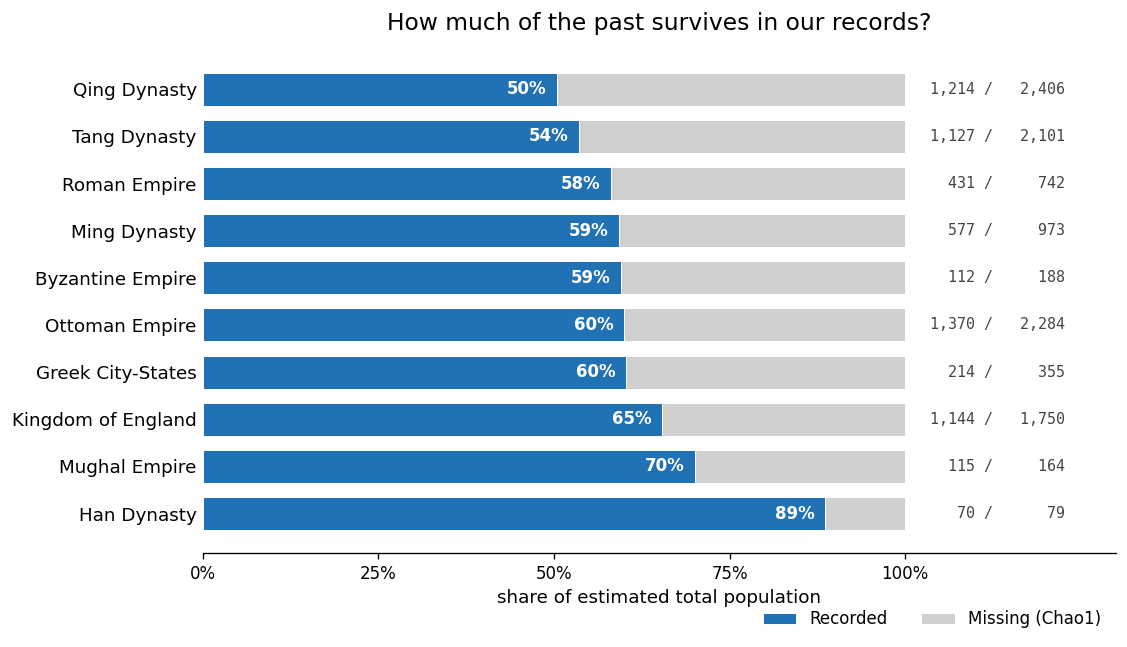

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE)
y = np.arange(snap.height)

recorded_pct = snap['survivorship'].to_numpy() * 100
missing_pct = 100 - recorded_pct

ax.barh(y, recorded_pct, color=COLOR_RECORDED, edgecolor="white", lw=0.6,
        label="Recorded", height=0.7)
ax.barh(y, missing_pct, left=recorded_pct, color=COLOR_LINK, edgecolor="white",
        lw=0.6, label="Missing (Chao1)", height=0.7)

for yi, r in zip(y, snap.iter_rows(named=True)):
    pct = r['survivorship'] * 100
    ax.text(pct - 1.5, yi, f"{pct:.0f}%", va="center", ha="right",
            fontsize=10, color="white", fontweight="bold")
    ax.text(101, yi, f"{r['n_obs']:>7,} / {int(round(r['n_chao'])):>7,}",
            va="center", ha="left", fontsize=9,
            color=COLOR_TEXT, family="monospace")

ax.set_yticks(y)
ax.set_yticklabels(snap['polity'].to_list())
ax.set_xlim(0, 130)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("share of estimated total population")
ax.set_title("How much of the past survives in our records?",
             fontsize=14, pad=12)
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right", fontsize=10,
          bbox_to_anchor=(1.0, -0.18), ncol=2)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()